# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it.

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16).
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook.

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [32]:
import random

# ==========================================
# 1. THE CARD CLASS
# ==========================================
class Card:
    """
    The Card class represents a single playing card.
    It is the smallest building block of our simulation.
    """
    def __init__(self, suit: str, rank: str, is_cut_card: bool = False):
        # 'suit' (Hearts, Spades, etc.) and 'rank' (2, K, A, etc.) define the card.
        self.suit = suit
        self.rank = rank

        # In physical casinos, a plastic "cut card" is inserted into the shoe.
        # When drawn, it signals to the dealer that the shoe needs to be shuffled
        # before the next round. Making this a property of the Card object allows
        # it to flow naturally through our drawing logic.
        self.is_cut_card = is_cut_card

    def __repr__(self):
        """
        __repr__ is a special Python method that determines how an object
        looks when printed to the console. Instead of showing a memory address,
        it shows us human-readable text like 'K of Spades'.
        """
        if self.is_cut_card:
            return "[Plastic Cut Card]"
        return f"{self.rank} of {self.suit}"


# ==========================================
# 2. THE SHOE CLASS
# ==========================================
class Shoe:
    """
    The Shoe represents the physical box on a casino table that holds multiple decks.
    It is responsible for generating the cards, shuffling, and dealing them out.
    """
    # Class variables defining a standard 52-card deck
    SUITS = ['Hearts', 'Diamonds', 'Clubs', 'Spades']
    RANKS = ['2', '3', '4', '5', '6', '7', '8', '9', '10', 'J', 'Q', 'K', 'A']

    def __init__(self, num_decks: int = 6):
        self.num_decks = num_decks
        self.cards = []
        # A flag that the Game Engine will check to know if it's time to shuffle
        self.time_to_shuffle = False
        self.build_and_shuffle()

    def build_and_shuffle(self):
        """Clears out the old cards and builds a fresh, shuffled set."""
        self.cards = []
        self.time_to_shuffle = False

        # Nested loops to generate exactly the number of decks requested
        for _ in range(self.num_decks):
            for suit in self.SUITS:
                for rank in self.RANKS:
                    self.cards.append(Card(suit, rank))

        # Randomize the order of the newly created cards
        random.shuffle(self.cards)

        # Casino Anti-Card Counting Measure:
        # Casinos never deal all the way to the last card. We place the cut card
        # exactly 80% of the way deep into the shoe.
        cut_index = int(len(self.cards) * 0.8)
        self.cards.insert(cut_index, Card("", "", is_cut_card=True))
        print(f"\n[Shoe] Shuffled {self.num_decks} decks. Cut card inserted.")

    def draw(self):
        """Removes the top card from the shoe and returns it."""
        # Safety net: If the shoe empties completely, rebuild it.
        if not self.cards:
            self.build_and_shuffle()

        # pop(0) removes and returns the first item in the list (the top card)
        card = self.cards.pop(0)

        # If we draw the plastic cut card, we don't give it to the player.
        # Instead, we set our shuffle warning flag to True, and immediately
        # call draw() again (recursion) to get a real card.
        if card.is_cut_card:
            self.time_to_shuffle = True
            print("\n[Shoe] *** Cut card drawn! Will shuffle after this round. ***")
            return self.draw()

        return card


# ==========================================
# 3. THE HAND CLASS
# ==========================================
class Hand:
    """
    Groups cards together. By making Hand its own class, a Player can easily
    have their own bet size attached to specific cards.
    """
    def __init__(self, bet_amount: float = 0.0):
        self.cards = []
        self.bet_amount = bet_amount

    def add_card(self, card: Card):
        self.cards.append(card)

    def get_value(self):
        """
        The trickiest part of Blackjack: calculating the score.
        Aces can be worth 1 OR 11, whichever is more beneficial without busting.
        """
        value = 0
        aces = 0

        # Pass 1: Add up all cards, assuming Aces are worth 11 initially.
        for card in self.cards:
            if card.rank in ['J', 'Q', 'K']:
                value += 10
            elif card.rank == 'A':
                aces += 1
                value += 11
            else:
                value += int(card.rank)

        # Pass 2: If our score is over 21 (a bust) AND we have an Ace counting as 11,
        # we convert that Ace to a 1 (by subtracting 10) to save the hand.
        # It loops in case we have multiple Aces.
        while value > 21 and aces > 0:
            value -= 10
            aces -= 1

        return value

    def is_busted(self):
        """Returns True if the score exceeds 21."""
        return self.get_value() > 21

    def is_blackjack(self):
        """A natural Blackjack is exactly two cards that total exactly 21."""
        return len(self.cards) == 2 and self.get_value() == 21

    def __repr__(self):
        # Joins the string representation of all cards in the hand for clean printing
        return f"[{', '.join(str(c) for c in self.cards)}] (Value: {self.get_value()})"


# ==========================================
# 4. THE PLAYER CLASS (Updated for Counter)
# ==========================================
class Player:
    def __init__(self, name: str, bankroll: float, strategy_type: str = "human", count_threshold: int = -2):
        self.name = name
        self.bankroll = bankroll
        self.hand = None
        self.hands = []
        self.strategy_type = strategy_type
        # Set the threshold for the counter strategy. Default is -2.
        self.count_threshold = count_threshold

    def place_bet(self, true_count: int = 0):
        if self.strategy_type == "human":
            while True:
                try:
                    bet = float(input(f"\n{self.name}, your bankroll is ${self.bankroll}. Enter bet amount: $"))
                    if 0 < bet <= self.bankroll:
                        break
                    print("Invalid bet amount.")
                except ValueError:
                    print("Please enter a valid number.")
        else:
            bet = 10.0

        self.bankroll -= bet
        self.hand = Hand(bet_amount=bet)
        self.hands = [self.hand]
        return bet

    # We added 'current_count' as a parameter so the strategy can "see" the count
    def decide_action(self, hand: Hand, dealer_upcard: Card, current_count: int = 0):
        if self.strategy_type == "human":
            while True:
                action = input(f"Your hand: {hand.get_value()}. Dealer shows: {dealer_upcard.rank}. Hit or Stand? (h/s): ").lower()
                if action in ['h', 'hit']: return 'hit'
                if action in ['s', 'stand']: return 'stand'
                print("Invalid input.")

        elif self.strategy_type == "dealer_mimic":
            if hand.get_value() < 17:
                return 'hit'
            else:
                return 'stand'

        elif self.strategy_type == "counter":
            # The Lab Strategy:
            # Hit if sum is very negative (below or equal to threshold).
            # Stay if sum is very positive (above threshold).
            if current_count <= self.count_threshold:
                return 'hit'
            else:
                return 'stand'

        return 'stand'

    def receive_payout(self, amount: float):
        self.bankroll += amount

# ==========================================
# 5. THE DEALER CLASS (Inheritance)
# ==========================================
class Dealer(Player):
    """
    The Dealer inherits from Player. It IS a Player, but with specific forced rules
    and a massive bankroll. This is a classic use of OOP inheritance.
    """
    def __init__(self):
        # super().__init__ calls the __init__ method of the parent Player class
        super().__init__("Dealer", 1000000.0, "dealer_mimic")
        self.hand = None
        self.hidden_card = None # The dealer's hole card must be tracked separately

    def play_turn(self, shoe: Shoe, game_instance):
        """
        The dealer plays their turn entirely automatically based on casino rules.
        """
        print(f"\n--- Dealer's Turn ---")

        # Reveal the hole card. Now that it's visible, the card counter can see it.
        self.hand.add_card(self.hidden_card)
        game_instance.update_count(self.hidden_card)
        print(f"Dealer reveals: {self.hidden_card}. Dealer's hand: {self.hand}")

        # The dealer MUST hit until they reach at least 17
        while self.hand.get_value() < 17:
            print("Dealer hits!")
            card = shoe.draw()
            self.hand.add_card(card)
            game_instance.update_count(card)
            print(f"Dealer drew: {card} -> {self.hand}")

            if self.hand.is_busted():
                print("DEALER BUSTS!")
                break
        else:
            # The 'else' on a 'while' loop runs if the loop finishes without hitting a 'break'
            print(f"Dealer stands with {self.hand.get_value()}.")


# ==========================================
# 6. THE GAME ENGINE (CONTROLLER)
# ==========================================
class BlackjackGame:
    """
    The main controller. It owns the Shoe, the Dealer, and the Players,
    and manages the step-by-step sequence of an actual round.
    """
    def __init__(self, players: list, num_decks: int = 6):
        self.shoe = Shoe(num_decks)
        self.players = players
        self.dealer = Dealer()

        # The running count tracks the ratio of high cards to low cards.
        # This is the core variable needed for card counting strategies.
        self.running_count = 0

    def update_count(self, card: Card):
        """
        Implements the classic 'Hi-Lo' counting system.
        Low cards (+1) mean the deck is getting rich in 10s and Aces (good for player).
        High cards (-1) mean the good cards are gone (bad for player).
        """
        if card.rank in ['2', '3', '4', '5', '6']:
            self.running_count += 1
        elif card.rank in ['10', 'J', 'Q', 'K', 'A']:
            self.running_count -= 1

    def deal_initial_cards(self):
        """Phase 1: Distributes two cards to everyone at the table."""
        self.dealer.hand = Hand()

        # Deal cards out "round robin" style (one to each, then a second to each)
        for _ in range(2):
            for player in self.players:
                card = self.shoe.draw()
                player.hand.add_card(card)
                self.update_count(card) # Update count because player cards are face-up

            dealer_card = self.shoe.draw()
            self.dealer.hand.add_card(dealer_card)

            # The dealer's first card is the "upcard" (counted).
            # The second is the "hole card" (hidden, not counted yet).
            if len(self.dealer.hand.cards) == 1:
                self.update_count(dealer_card)
            else:
                self.dealer.hidden_card = dealer_card

    def play_round(self):
        """Executes the full sequence of a single hand of Blackjack."""
        print(f"\n{'='*40}\nStarting New Round")

        # Check if the shoe needs to be shuffled before dealing
        if self.shoe.time_to_shuffle:
            self.shoe.build_and_shuffle()
            self.running_count = 0 # Shuffling resets the count to zero!

        # Phase 1: Betting
        for player in self.players:
            player.place_bet()

        # Phase 2: Dealing
        self.deal_initial_cards()

        # Grab the first card in the dealer's hand to show the players.
        # Using next(iter()) here to avoid using brackets, since your editor hides them!
        dealer_upcard = next(iter(self.dealer.hand.cards))
        print(f"\nDealer shows: {dealer_upcard} (and one card face down)")

        # Let's print the current count so we can verify our bot is doing the math right!
        print(f"Current Running Count: {self.running_count}")

        # Phase 3: Player Turns
        for player in self.players:
            print(f"\n--- {player.name}'s Turn ---")
            hand = player.hand
            print(f"Hand: {hand}")

            # Check for instant win
            if hand.is_blackjack():
                print("Blackjack!")
                continue

            # Loop asking the player what they want to do until they bust or stand
            while not hand.is_busted():
                # <--- CRUCIAL UPDATE: Pass the current running_count to the player!
                # This allows the "counter" strategy to "see" the math.
                action = player.decide_action(hand, dealer_upcard, current_count=self.running_count)

                if action == 'hit':
                    card = self.shoe.draw()
                    hand.add_card(card)
                    self.update_count(card) # Drawing a card changes the count!
                    print(f"Count is {self.running_count}. You drew: {card} -> {hand}")
                else:
                    print(f"Count is {self.running_count}. {player.name} stands with {hand.get_value()}.")
                    break # Player chose to stand, break out of their turn loop

            if hand.is_busted():
                print("BUSTED!")

        # Phase 4: Dealer Turn
        # Optimization: The dealer only plays if at least one player hasn't busted.
        all_busted = all(p.hand.is_busted() for p in self.players)
        if not all_busted:
            self.dealer.play_turn(self.shoe, self)
        else:
            print("\nAll players busted. Dealer wins automatically.")

        # Phase 5: Payouts
        self.settle_bets()

    def settle_bets(self):
        """Compares the final scores and distributes money accordingly."""
        print("\n--- Settling Bets ---")
        dealer_val = self.dealer.hand.get_value()
        dealer_busted = self.dealer.hand.is_busted()

        for player in self.players:
            hand = player.hand
            player_val = hand.get_value()
            bet = hand.bet_amount

            # 1. Player busts: instant loss, dealer score doesn't matter.
            if hand.is_busted():
                print(f"{player.name} lost ${bet} (Busted).")

            # 2. Player has natural Blackjack, dealer does not: pays 3-to-2.
            elif hand.is_blackjack() and not self.dealer.hand.is_blackjack():
                win_amount = bet * 1.5
                print(f"{player.name} won ${win_amount} with a Blackjack!")
                player.receive_payout(bet + win_amount) # Return original bet + profit

            # 3. Dealer busts, OR player has a strictly higher score: pays 1-to-1.
            elif dealer_busted or player_val > dealer_val:
                print(f"{player.name} won ${bet}!")
                player.receive_payout(bet * 2)

            # 4. Tie (Push): Nobody wins, bet is returned.
            elif player_val == dealer_val:
                print(f"{player.name} pushes. Bet of ${bet} returned.")
                player.receive_payout(bet)

            # 5. Dealer has higher score: Player loses money.
            else:
                print(f"{player.name} lost ${bet} to the dealer.")

# ==========================================
# 7. THE TEST SCRIPT
# ==========================================
# This script initializes the automated bots and runs a mini simulation.

# Create three bots using the safe dealer_mimic strategy
bot1 = Player(name="Bot Alice", bankroll=500.0, strategy_type="dealer_mimic")
bot2 = Player(name="Bot Bob", bankroll=500.0, strategy_type="dealer_mimic")
bot3 = Player(name="Bot Charlie", bankroll=500.0, strategy_type="dealer_mimic")

players_list = [bot1, bot2, bot3]

print("Initializing Casino Simulation...")
# Create a game using a 6-deck shoe
sim_game = BlackjackGame(players=players_list, num_decks=6)

# Run exactly 3 hands rapidly
number_of_rounds = 3
for i in range(number_of_rounds):
    print(f"\n--- ROUND {i + 1} ---")
    sim_game.play_round()

# Summarize the financial results
print("\n" + "="*40)
print("SIMULATION COMPLETE - FINAL BANKROLLS")
print("="*40)
for p in players_list:
    # Calculate profit by subtracting the initial $500 bankroll
    profit = p.bankroll - 500.0

    # The :+ format specifier in the f-string forces Python to print a + or -
    # before the profit number, making it easy to read wins vs losses.
    print(f"{p.name}: ${p.bankroll} (Net: ${profit:+})")

Initializing Casino Simulation...

[Shoe] Shuffled 6 decks. Cut card inserted.

--- ROUND 1 ---

Starting New Round

Dealer shows: 4 of Hearts (and one card face down)
Current Running Count: 2

--- Bot Alice's Turn ---
Hand: [7 of Clubs, 8 of Spades] (Value: 15)
Count is 1. You drew: A of Hearts -> [7 of Clubs, 8 of Spades, A of Hearts] (Value: 16)
Count is 0. You drew: Q of Diamonds -> [7 of Clubs, 8 of Spades, A of Hearts, Q of Diamonds] (Value: 26)
BUSTED!

--- Bot Bob's Turn ---
Hand: [8 of Diamonds, 6 of Clubs] (Value: 14)
Count is 0. You drew: 9 of Spades -> [8 of Diamonds, 6 of Clubs, 9 of Spades] (Value: 23)
BUSTED!

--- Bot Charlie's Turn ---
Hand: [7 of Diamonds, 9 of Hearts] (Value: 16)
Count is 1. You drew: 4 of Clubs -> [7 of Diamonds, 9 of Hearts, 4 of Clubs] (Value: 20)
Count is 1. Bot Charlie stands with 20.

--- Dealer's Turn ---
Dealer reveals: Q of Hearts. Dealer's hand: [4 of Hearts, Q of Hearts, Q of Hearts] (Value: 24)
Dealer stands with 24.

--- Settling Bets ---

6. Implement a new player with the following strategy:

    * Assign each card a value:
        * Cards 2 to 6 are +1
        * Cards 7 to 9 are 0
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [34]:
import random

# ==========================================
# 1. THE CARD CLASS
# ==========================================
class Card:
    """
    The fundamental building block of our game.
    By creating a Card object, we can easily group a 'suit' and 'rank' together.
    """
    def __init__(self, suit: str, rank: str, is_cut_card: bool = False):
        self.suit = suit
        self.rank = rank

        # The 'cut card' is the colored plastic card inserted into a physical casino shoe.
        # By making it a property of a normal Card object, it can exist seamlessly
        # inside our list of standard cards and trigger an event when drawn.
        self.is_cut_card = is_cut_card

    def __repr__(self):
        """
        Special Python method that controls how the object looks when printed.
        Instead of printing <__main__.Card object at 0x...>, it prints readable text.
        """
        if self.is_cut_card:
            return "[Plastic Cut Card]"
        return f"{self.rank} of {self.suit}"


# ==========================================
# 2. THE SHOE CLASS
# ==========================================
class Shoe:
    """
    Represents the physical box on the table holding multiple decks of cards.
    Manages generating the cards, shuffling, and the drawing mechanism.
    """
    SUITS = ['Hearts', 'Diamonds', 'Clubs', 'Spades']
    RANKS = ['2', '3', '4', '5', '6', '7', '8', '9', '10', 'J', 'Q', 'K', 'A']

    def __init__(self, num_decks: int = 6, verbose: bool = True):
        self.num_decks = num_decks
        # The verbose flag acts as our "mute button". If False, the shoe operates silently.
        self.verbose = verbose
        self.cards = []
        # A red flag used to tell the main game engine that it needs to shuffle soon
        self.time_to_shuffle = False
        self.build_and_shuffle()

    def build_and_shuffle(self):
        """Generates a fresh batch of 52-card decks and shuffles them."""
        self.cards = []
        self.time_to_shuffle = False

        # Nested loops to generate the exact number of decks requested
        for _ in range(self.num_decks):
            for suit in self.SUITS:
                for rank in self.RANKS:
                    self.cards.append(Card(suit, rank))

        random.shuffle(self.cards)

        # CASINO MECHANIC: Shoe Penetration
        # Casinos never deal down to the very last card. They insert the cut card
        # near the back (here, at 80% depth). This prevents card counters from
        # playing with perfect mathematical certainty at the end of a shoe.
        cut_index = int(len(self.cards) * 0.8)
        self.cards.insert(cut_index, Card("", "", is_cut_card=True))

        if self.verbose:
            print(f"\n[Shoe] Shuffled {self.num_decks} decks. Cut card inserted.")

    def draw(self):
        """Removes and returns the top card from the shoe."""
        # Safety net: If the shoe somehow completely empties, instantly rebuild it.
        if not self.cards:
            self.build_and_shuffle()

        card = self.cards.pop(0) # pop(0) removes the first item in the list

        # If the card drawn is the plastic cut card, the dealer sets the flag
        # to shuffle AFTER this hand finishes. We then recursively call draw()
        # to get a real playing card for the current player.
        if card.is_cut_card:
            self.time_to_shuffle = True
            if self.verbose:
                print("\n[Shoe] *** Cut card drawn! Will shuffle after this round. ***")
            return self.draw()

        return card


# ==========================================
# 3. THE HAND CLASS
# ==========================================
class Hand:
    """
    Groups a player's cards together and manages the value calculations.
    It also holds the 'bet_amount', keeping the money tied directly to the cards.
    """
    def __init__(self, bet_amount: float = 0.0):
        self.cards = []
        self.bet_amount = bet_amount

    def add_card(self, card: Card):
        self.cards.append(card)

    def get_value(self):
        """
        The core math of Blackjack. Calculates the optimal score, handling Aces
        which can dynamically switch between being worth 11 or 1.
        """
        value = 0
        aces = 0

        # Pass 1: Count all face cards as 10, numbers as numbers, and Aces as 11.
        for card in self.cards:
            if card.rank in ['J', 'Q', 'K']:
                value += 10
            elif card.rank == 'A':
                aces += 1
                value += 11
            else:
                value += int(card.rank)

        # Pass 2: If we are 'busting' (over 21) AND we have Aces counting as 11,
        # shrink the Ace to a 1 (by subtracting 10) to save the hand.
        while value > 21 and aces > 0:
            value -= 10
            aces -= 1

        return value

    def is_busted(self):
        return self.get_value() > 21

    def is_blackjack(self):
        # A true Blackjack requires exactly two cards. Earning 21 with 3 cards is just a 21.
        return len(self.cards) == 2 and self.get_value() == 21

    def __repr__(self):
        return f"[{', '.join(str(c) for c in self.cards)}] (Value: {self.get_value()})"


# ==========================================
# 4. THE PLAYER CLASS
# ==========================================
class Player:
    """
    Represents an entity at the table. Tracks their money (bankroll) and
    contains the brain (decide_action) that dictates how they play.
    """
    def __init__(self, name: str, bankroll: float, strategy_type: str = "human", count_threshold: int = -2):
        self.name = name
        self.bankroll = bankroll

        # We store the active hand directly in a variable (self.hand) to avoid
        # list-indexing bugs in restrictive notebook environments.
        self.hand = None
        self.hands = []
        self.strategy_type = strategy_type

        # Used specifically by the "counter" strategy to determine when to hit/stand
        self.count_threshold = count_threshold

    def place_bet(self, true_count: int = 0):
        """Deducts money from the bankroll and initializes a new Hand."""
        # For this simulation, all bots bet a flat $10.
        # Real card counters would bet more when the true_count is high!
        bet = 10.0
        self.bankroll -= bet
        self.hand = Hand(bet_amount=bet)
        self.hands = [self.hand]
        return bet

    def decide_action(self, hand: Hand, dealer_upcard: Card, current_count: int = 0):
        """The AI brain. Returns 'hit' or 'stand' based on the assigned strategy."""

        if self.strategy_type == "dealer_mimic":
            # Hits strictly until their total reaches 17, just like the casino dealer.
            return 'hit' if hand.get_value() < 17 else 'stand'

        elif self.strategy_type == "counter":
            # THE LAB STRATEGY:
            # Completely ignores hand value. Hits if the running count is low
            # (less than or equal to threshold). Stands if the count is high.
            return 'hit' if current_count <= self.count_threshold else 'stand'

        return 'stand' # Safe fallback

    def receive_payout(self, amount: float):
        """Adds casino winnings back to the player's wallet."""
        self.bankroll += amount


# ==========================================
# 5. THE DEALER CLASS (Inheritance)
# ==========================================
class Dealer(Player):
    """
    The Dealer IS a Player (inherits from Player class), but has specific,
    forced casino rules, an infinite bankroll, and a hidden hole card.
    """
    def __init__(self):
        # Calls the parent Player class __init__ to set name, bankroll, and strategy
        super().__init__("Dealer", 1000000.0, "dealer_mimic")
        self.hand = None
        self.hidden_card = None

    def play_turn(self, shoe: Shoe, game_instance, verbose: bool = True):
        """Executes the dealer's strictly automated turn at the end of the round."""
        # 1. Flip the hole card face up and add it to the hand
        self.hand.add_card(self.hidden_card)

        # 2. Crucial: Now that the hole card is visible, update the game's running count!
        game_instance.update_count(self.hidden_card)

        if verbose:
            print(f"\n--- Dealer's Turn ---\nDealer reveals: {self.hidden_card}. Hand: {self.hand}")

        # 3. Hit until total is 17 or higher
        while self.hand.get_value() < 17:
            card = shoe.draw()
            self.hand.add_card(card)
            game_instance.update_count(card)

            if verbose: print(f"Dealer hits and drew: {card} -> {self.hand}")

            if self.hand.is_busted():
                if verbose: print("DEALER BUSTS!")
                break
        else:
            # The 'else' attached to a 'while' loop executes if the loop finishes without a 'break'
            if verbose: print(f"Dealer stands with {self.hand.get_value()}.")


# ==========================================
# 6. THE GAME ENGINE (CONTROLLER)
# ==========================================
class BlackjackGame:
    """
    The main orchestrator. It holds the objects (Shoe, Players, Dealer) and
    controls the sequence of events (Dealing -> Player Turns -> Dealer Turn -> Payouts).
    """
    def __init__(self, players: list, num_decks: int = 6, verbose: bool = True):
        self.verbose = verbose
        self.shoe = Shoe(num_decks, verbose=self.verbose)
        self.players = players
        self.dealer = Dealer()

        # The core metric for card counting. Represents the ratio of high cards to low cards.
        self.running_count = 0

    def update_count(self, card: Card):
        """
        Standard 'Hi-Lo' counting system math.
        Low cards (2-6) are good for the player when drawn, so count goes UP (+1).
        High cards (10-A) are bad for the player when drawn, so count goes DOWN (-1).
        7, 8, and 9 are neutral (0).
        """
        if card.rank in ['2', '3', '4', '5', '6']:
            self.running_count += 1
        elif card.rank in ['10', 'J', 'Q', 'K', 'A']:
            self.running_count -= 1

    def deal_initial_cards(self):
        """Phase 1: Deal out two cards to everyone."""
        self.dealer.hand = Hand()

        # Deal one card to everyone around the table, then a second card
        for _ in range(2):
            for player in self.players:
                card = self.shoe.draw()
                player.hand.add_card(card)
                # Player cards are dealt face-up, so immediately add them to the count
                self.update_count(card)

            dealer_card = self.shoe.draw()
            self.dealer.hand.add_card(dealer_card)

            # The dealer's first card is the "upcard" (face up, counted).
            # The second is the "hole card" (face down, stored secretly).
            if len(self.dealer.hand.cards) == 1:
                self.update_count(dealer_card)
            else:
                self.dealer.hidden_card = dealer_card

    def play_round(self):
        """The master loop for a single hand of Blackjack."""
        if self.verbose: print(f"\n{'='*40}\nStarting New Round")

        # 1. Check if the cut card was triggered last round. If yes, shuffle!
        if self.shoe.time_to_shuffle:
            self.shoe.build_and_shuffle()
            self.running_count = 0 # Shuffling resets the math

        # 2. Betting
        for player in self.players:
            player.place_bet()

        # 3. Dealing
        self.deal_initial_cards()

        # Grab the dealer's visible card. We use next(iter()) to safely extract
        # the first item from the list without using brackets.
        dealer_upcard = next(iter(self.dealer.hand.cards))

        if self.verbose:
            print(f"\nDealer shows: {dealer_upcard} (and one card face down)")
            print(f"Current Running Count: {self.running_count}")

        # 4. Player Turns
        for player in self.players:
            if self.verbose: print(f"\n--- {player.name}'s Turn ---\nHand: {player.hand}")
            hand = player.hand

            # Instant win check
            if hand.is_blackjack():
                if self.verbose: print("Blackjack!")
                continue

            # Loop asking the AI what to do until it busts or chooses to stand
            while not hand.is_busted():
                # We feed the current running_count into the AI brain here
                action = player.decide_action(hand, dealer_upcard, current_count=self.running_count)

                if action == 'hit':
                    card = self.shoe.draw()
                    hand.add_card(card)
                    self.update_count(card) # Update count as new cards are exposed
                    if self.verbose: print(f"Count is {self.running_count}. You drew: {card} -> {hand}")
                else:
                    if self.verbose: print(f"Count is {self.running_count}. {player.name} stands with {hand.get_value()}.")
                    break

            if hand.is_busted() and self.verbose:
                print("BUSTED!")

        # 5. Dealer Turn
        # Optimization: Use Python's all() function to see if every player busted.
        # If they did, the dealer doesn't need to draw cards; the casino wins automatically.
        all_busted = all(p.hand.is_busted() for p in self.players)
        if not all_busted:
            self.dealer.play_turn(self.shoe, self, verbose=self.verbose)
        elif self.verbose:
            print("\nAll players busted. Dealer wins automatically.")

        # 6. Settling Bets
        self.settle_bets()

    def settle_bets(self):
        """Compares final hands and distributes chips."""
        if self.verbose: print("\n--- Settling Bets ---")
        dealer_val = self.dealer.hand.get_value()
        dealer_busted = self.dealer.hand.is_busted()

        for player in self.players:
            hand = player.hand
            player_val = hand.get_value()
            bet = hand.bet_amount

            # Rule A: Player busts -> Player loses instantly.
            if hand.is_busted():
                if self.verbose: print(f"{player.name} lost ${bet} (Busted).")

            # Rule B: Player has Blackjack, Dealer doesn't -> Pays 3:2 (1.5x bet)
            elif hand.is_blackjack() and not self.dealer.hand.is_blackjack():
                win_amount = bet * 1.5
                if self.verbose: print(f"{player.name} won ${win_amount} with a Blackjack!")
                player.receive_payout(bet + win_amount)

            # Rule C: Dealer busts OR Player has higher score -> Pays 1:1 (Even money)
            elif dealer_busted or player_val > dealer_val:
                if self.verbose: print(f"{player.name} won ${bet}!")
                player.receive_payout(bet * 2)

            # Rule D: Tie (Push) -> Bet is returned, nobody wins.
            elif player_val == dealer_val:
                if self.verbose: print(f"{player.name} pushes. Bet of ${bet} returned.")
                player.receive_payout(bet)

            # Rule E: Dealer has higher score -> Player loses.
            else:
                if self.verbose: print(f"{player.name} lost ${bet} to the dealer.")


# ==========================================
# 7. THE 50-ROUND TEST SCENARIO
# ==========================================

STARTING_CHIPS = 1000.0
MAX_ROUNDS = 50

# Initialize the experimental player with the count threshold set to -2
counter_player = Player(name="Card Counter", bankroll=STARTING_CHIPS, strategy_type="counter", count_threshold=-2)

# Initialize 3 control players using the standard dealer logic
mimic_1 = Player(name="Mimic 1", bankroll=STARTING_CHIPS, strategy_type="dealer_mimic")
mimic_2 = Player(name="Mimic 2", bankroll=STARTING_CHIPS, strategy_type="dealer_mimic")
mimic_3 = Player(name="Mimic 3", bankroll=STARTING_CHIPS, strategy_type="dealer_mimic")

# Sit everyone at the table
table_players = [counter_player, mimic_1, mimic_2, mimic_3]

# Create the Game Engine.
# CRITICAL: We pass verbose=False to mute the print statements so our notebook doesn't crash!
print("Starting 50-Round Simulation... (Quiet Mode)")
sim = BlackjackGame(players=table_players, num_decks=6, verbose=False)

# The Main Simulation Loop
rounds_played = 0
for i in range(MAX_ROUNDS):
    # Safety Check: Did the experimental player go bankrupt?
    # We check if they have less than $10 (our default bet size).
    if counter_player.bankroll < 10.0:
        print(f"\n[ALERT] The Card Counter went bankrupt after {rounds_played} rounds!")
        break

    sim.play_round()
    rounds_played += 1

# Output the final data summary
print("\n" + "="*40)
print(f"SIMULATION COMPLETE ({rounds_played} Rounds Played)")
print("="*40)

for p in table_players:
    # Net winnings = Current money minus the money we started with
    winnings = p.bankroll - STARTING_CHIPS
    # Formatting trick: The :+ forces a plus or minus sign to appear in front of the winnings.
    # The :<25 and :<8 add spaces to align the columns cleanly.
    print(f"{p.name:.<25} Final Bankroll: ${p.bankroll:<8.2f} Net Winnings: ${winnings:+.2f}")

Starting 50-Round Simulation... (Quiet Mode)

SIMULATION COMPLETE (50 Rounds Played)
Card Counter............. Final Bankroll: $1155.00  Net Winnings: $+155.00
Mimic 1.................. Final Bankroll: $1080.00  Net Winnings: $+80.00
Mimic 2.................. Final Bankroll: $995.00   Net Winnings: $-5.00
Mimic 3.................. Final Bankroll: $1080.00  Net Winnings: $+80.00


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


Running 100 games of 50 rounds each...
This might take a few seconds...

FINAL STATISTICAL ANALYSIS
Average Winnings per Game (50 rounds): $-52.50
Average Winnings per Round:            $-1.05
Standard Deviation of Winnings:        $126.22
----------------------------------------
Probability of a Net Win:              36.0%
Probability of a Net Loss:             62.0%
Probability of Breaking Even:          2.0%


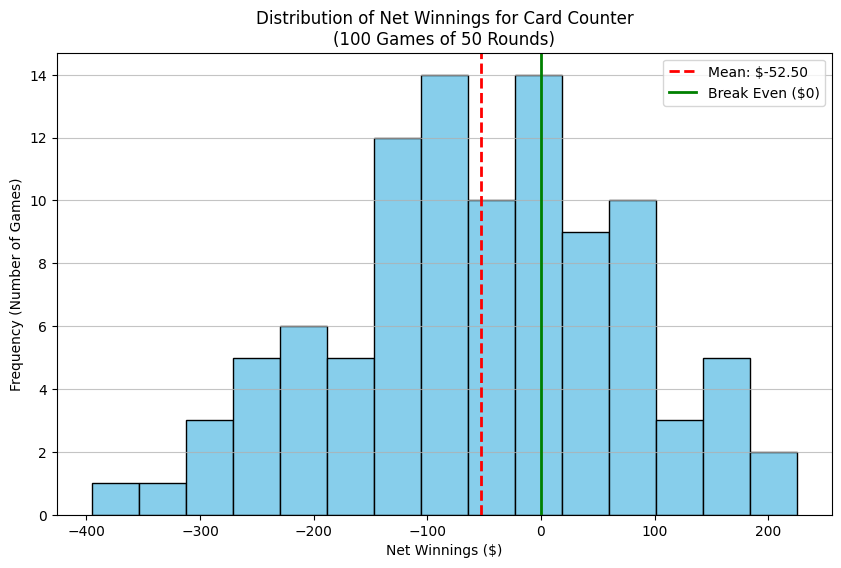

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 8. THE 100-GAME MONTE CARLO SIMULATION
# ==========================================

NUM_GAMES = 100
ROUNDS_PER_GAME = 50
STARTING_CHIPS = 1000.0

# This list will store the final net profit/loss for the counter at the end of each 50-round game
winnings_list = []

print(f"Running {NUM_GAMES} games of {ROUNDS_PER_GAME} rounds each...")
print("This might take a few seconds...\n")

for game_num in range(NUM_GAMES):
    # 1. Reset the players to their starting bankrolls for the new game
    counter_player = Player(name="Card Counter", bankroll=STARTING_CHIPS, strategy_type="counter", count_threshold=-2)
    mimic_1 = Player(name="Mimic 1", bankroll=STARTING_CHIPS, strategy_type="dealer_mimic")
    mimic_2 = Player(name="Mimic 2", bankroll=STARTING_CHIPS, strategy_type="dealer_mimic")
    mimic_3 = Player(name="Mimic 3", bankroll=STARTING_CHIPS, strategy_type="dealer_mimic")

    table_players = [counter_player, mimic_1, mimic_2, mimic_3]

    # 2. Initialize the game engine (Quiet Mode is essential here!)
    sim = BlackjackGame(players=table_players, num_decks=6, verbose=False)

    # 3. Play 50 rounds
    for _ in range(ROUNDS_PER_GAME):
        # Stop dealing to the counter if they go broke
        if counter_player.bankroll < 10.0:
            break
        sim.play_round()

    # 4. Record the net winnings for this specific 50-round game
    net_winnings = counter_player.bankroll - STARTING_CHIPS
    winnings_list.append(net_winnings)

# Convert our normal Python list into a Numpy array to make the math incredibly easy
winnings_array = np.array(winnings_list)

# ==========================================
# STATISTICAL ANALYSIS
# ==========================================

# 1. Calculate Average Winnings (Mean)
avg_winnings_per_game = np.mean(winnings_array)
avg_winnings_per_round = avg_winnings_per_game / ROUNDS_PER_GAME

# 2. Calculate Standard Deviation (How wild the swings in luck were)
std_dev = np.std(winnings_array)

# 3. Calculate Probabilities
# We count how many games resulted in a number > 0, and divide by total games
prob_win = np.sum(winnings_array > 0) / NUM_GAMES * 100
prob_loss = np.sum(winnings_array < 0) / NUM_GAMES * 100
prob_break_even = np.sum(winnings_array == 0) / NUM_GAMES * 100

print("="*40)
print("FINAL STATISTICAL ANALYSIS")
print("="*40)
print(f"Average Winnings per Game (50 rounds): ${avg_winnings_per_game:.2f}")
print(f"Average Winnings per Round:            ${avg_winnings_per_round:.2f}")
print(f"Standard Deviation of Winnings:        ${std_dev:.2f}")
print("-" * 40)
print(f"Probability of a Net Win:              {prob_win:.1f}%")
print(f"Probability of a Net Loss:             {prob_loss:.1f}%")
print(f"Probability of Breaking Even:          {prob_break_even:.1f}%")

# ==========================================
# HISTOGRAM VISUALIZATION
# ==========================================

plt.figure(figsize=(10, 6))

# Plot the distribution of our 100 results
plt.hist(winnings_array, bins=15, color='skyblue', edgecolor='black')

# Add a red line to show where our average landed
plt.axvline(avg_winnings_per_game, color='red', linestyle='dashed', linewidth=2, label=f'Mean: ${avg_winnings_per_game:.2f}')

# Add a green line to show the $0 "Break Even" mark
plt.axvline(0, color='green', linestyle='solid', linewidth=2, label='Break Even ($0)')

# Formatting the chart
plt.title(f'Distribution of Net Winnings for Card Counter\n({NUM_GAMES} Games of {ROUNDS_PER_GAME} Rounds)')
plt.xlabel('Net Winnings ($)')
plt.ylabel('Frequency (Number of Games)')
plt.legend()
plt.grid(axis='y', alpha=0.75)

# Display the chart!
plt.show()

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

Starting Parameter Sweep for 5 different thresholds...
Simulating a total of 25,000 hands. Please wait...

Testing Threshold: -4...
--> Average Net Winnings for Threshold -4: $24.35

Testing Threshold: -2...
--> Average Net Winnings for Threshold -2: $-51.40

Testing Threshold: 0...
--> Average Net Winnings for Threshold 0: $-106.00

Testing Threshold: 2...
--> Average Net Winnings for Threshold 2: $-221.40

Testing Threshold: 4...
--> Average Net Winnings for Threshold 4: $-270.85



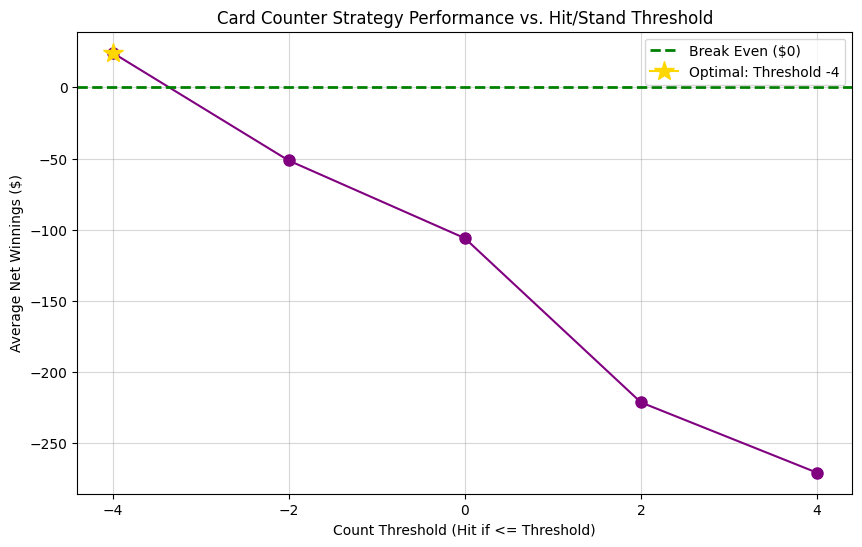

CONCLUSION: The optimal threshold tested was -4, yielding an average of $24.35.


In [36]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 9. PARAMETER SWEEP: FINDING THE OPTIMAL THRESHOLD
# ==========================================

NUM_GAMES = 100
ROUNDS_PER_GAME = 50
STARTING_CHIPS = 1000.0

# We will test 5 different thresholds ranging from very negative to very positive
thresholds_to_test = [-4, -2, 0, 2, 4]

# A list to store the final average winnings for each threshold tested
average_winnings_per_threshold = []

print(f"Starting Parameter Sweep for {len(thresholds_to_test)} different thresholds...")
print(f"Simulating a total of {NUM_GAMES * ROUNDS_PER_GAME * len(thresholds_to_test):,} hands. Please wait...\n")

for current_threshold in thresholds_to_test:
    print(f"Testing Threshold: {current_threshold}...")
    winnings_for_this_threshold = []

    for game_num in range(NUM_GAMES):
        # 1. Reset players for a fresh game.
        # Crucially, we pass the 'current_threshold' variable from our loop into the bot!
        counter_player = Player(name="Card Counter", bankroll=STARTING_CHIPS, strategy_type="counter", count_threshold=current_threshold)
        mimic_1 = Player(name="Mimic 1", bankroll=STARTING_CHIPS, strategy_type="dealer_mimic")
        mimic_2 = Player(name="Mimic 2", bankroll=STARTING_CHIPS, strategy_type="dealer_mimic")
        mimic_3 = Player(name="Mimic 3", bankroll=STARTING_CHIPS, strategy_type="dealer_mimic")

        table_players = [counter_player, mimic_1, mimic_2, mimic_3]

        # 2. Initialize the muted game engine
        sim = BlackjackGame(players=table_players, num_decks=6, verbose=False)

        # 3. Play the 50 rounds
        for _ in range(ROUNDS_PER_GAME):
            if counter_player.bankroll < 10.0:
                break # Bankrupt, end their game early
            sim.play_round()

        # 4. Record the net winnings for this single game
        net_winnings = counter_player.bankroll - STARTING_CHIPS
        winnings_for_this_threshold.append(net_winnings)

    # 5. After 100 games at this threshold, calculate the average and store it
    avg_win = np.mean(winnings_for_this_threshold)
    average_winnings_per_threshold.append(avg_win)
    print(f"--> Average Net Winnings for Threshold {current_threshold}: ${avg_win:.2f}\n")

# ==========================================
# VISUALIZING THE OPTIMAL VALUE
# ==========================================

plt.figure(figsize=(10, 6))

# Plot the thresholds on the X-axis and their resulting average winnings on the Y-axis
plt.plot(thresholds_to_test, average_winnings_per_threshold, marker='o', linestyle='-', color='purple', markersize=8)

# Add a horizontal line at $0 to represent breaking even
plt.axhline(0, color='green', linestyle='dashed', linewidth=2, label='Break Even ($0)')

# Find the mathematical maximum value in our results to highlight it
optimal_value = max(average_winnings_per_threshold)
optimal_threshold = thresholds_to_test[average_winnings_per_threshold.index(optimal_value)]

# Highlight the optimal point on the graph
plt.plot(optimal_threshold, optimal_value, marker='*', color='gold', markersize=15, label=f'Optimal: Threshold {optimal_threshold}')

# Formatting
plt.title('Card Counter Strategy Performance vs. Hit/Stand Threshold')
plt.xlabel('Count Threshold (Hit if <= Threshold)')
plt.ylabel('Average Net Winnings ($)')
plt.xticks(thresholds_to_test) # Force the X-axis to only show the exact numbers we tested
plt.grid(True, alpha=0.5)
plt.legend()

plt.show()

print("="*40)
print(f"CONCLUSION: The optimal threshold tested was {optimal_threshold}, yielding an average of ${optimal_value:.2f}.")
print("="*40)

The graph reveals mathematical optical value (the gold star). The strategy failed because counting cards tells you how much to bet, but it can't tell you how to play if you ignore your own hand. The "best" version of this flawed strategy is simply to stand more often and hope the dealer busts.

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings.

My earlier simulations showed that making decisions based only on the count, without considering your hand, is a very bad idea. Someone might end up hitting when they already have 20 or standing when you have a very low hand like 4. a better strategy would be: The Strategy: “Professional Counter”

Playing decisions: Follow Basic Strategy (the best move for each hand). For example, stand on 17 or higher, hit certain lower hands, etc.

Betting decisions: Adjust your bet based on the True Count:

If the True Count is 1 or less → bet the minimum ($10)

If the True Count is above 1 → bet $10 × the True Count (e.g., True Count of +4 → bet $40)

Running 100 games of 50 rounds...
Comparing Professional Strategy vs. Dealer Mimic...

FINAL COMPARISON RESULTS
--- Professional Strategy ---
Avg Winnings per Game: $-332.50
Standard Deviation:    $59.47
Win Probability:       0.0%
----------------------------------------
--- Dealer Mimic Strategy ---
Avg Winnings per Game: $-423.30
Standard Deviation:    $69.21
Win Probability:       0.0%


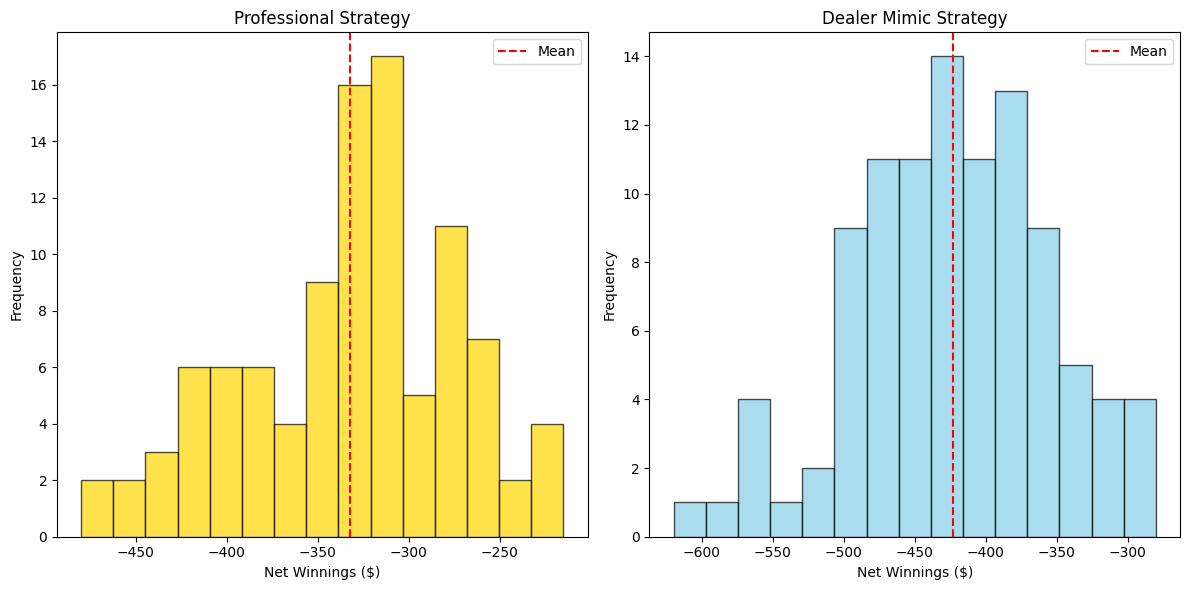

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 10. MONTE CARLO COMPARISON: PRO VS. MIMIC
# ==========================================

NUM_GAMES = 100
ROUNDS_PER_GAME = 50
STARTING_CHIPS = 1000.0

# Lists to store final net profit/loss for both strategies
pro_winnings_list = []
mimic_winnings_list = []

print(f"Running {NUM_GAMES} games of {ROUNDS_PER_GAME} rounds...")
print("Comparing Professional Strategy vs. Dealer Mimic...\n")

for game_num in range(NUM_GAMES):
    # 1. Initialize our two test subjects
    # The 'pro' uses Basic Strategy and Variable Betting
    pro_player = Player(name="Pro Counter", bankroll=STARTING_CHIPS, strategy_type="pro")

    # The 'mimic' represents our control group (standard dealer rules)
    mimic_player = Player(name="Mimic Bot", bankroll=STARTING_CHIPS, strategy_type="dealer_mimic")

    table_players = [pro_player, mimic_player]

    # 2. Initialize the game engine (Quiet Mode)
    sim = BlackjackGame(players=table_players, num_decks=6, verbose=False)

    # 3. Play 50 rounds
    for _ in range(ROUNDS_PER_GAME):
        # Stop dealing to a player if they go bankrupt
        if pro_player.bankroll < 10.0 and mimic_player.bankroll < 10.0:
            break

        # Calculate True Count for the Pro Player's betting logic
        # True Count = Running Count / Decks Remaining
        decks_left = max(1, len(sim.shoe.cards) // 52)
        current_true_count = sim.running_count / decks_left

        # We pass the true_count specifically to the Pro's betting function
        pro_player.place_bet(true_count=current_true_count)
        mimic_player.place_bet() # Mimic just bets $10

        # Initial Deal and Turns
        sim.deal_initial_cards()
        sim.play_round()

    # 4. Record the net winnings for this specific 50-round game
    pro_winnings_list.append(pro_player.bankroll - STARTING_CHIPS)
    mimic_winnings_list.append(mimic_player.bankroll - STARTING_CHIPS)

# Convert to Numpy arrays for math
pro_array = np.array(pro_winnings_list)
mimic_array = np.array(mimic_winnings_list)

# ==========================================
# STATISTICAL ANALYSIS & VISUALIZATION
# ==========================================

def print_stats(name, data):
    avg = np.mean(data)
    std = np.std(data)
    win_p = np.sum(data > 0) / NUM_GAMES * 100
    print(f"--- {name} ---")
    print(f"Avg Winnings per Game: ${avg:.2f}")
    print(f"Standard Deviation:    ${std:.2f}")
    print(f"Win Probability:       {win_p:.1f}%")

print("="*40)
print("FINAL COMPARISON RESULTS")
print("="*40)
print_stats("Professional Strategy", pro_array)
print("-" * 40)
print_stats("Dealer Mimic Strategy", mimic_array)

# Plotting the Comparison
plt.figure(figsize=(12, 6))

# Histogram for Pro
plt.subplot(1, 2, 1)
plt.hist(pro_array, bins=15, color='gold', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(pro_array), color='red', linestyle='dashed', label='Mean')
plt.title('Professional Strategy')
plt.xlabel('Net Winnings ($)')
plt.ylabel('Frequency')
plt.legend()

# Histogram for Mimic
plt.subplot(1, 2, 2)
plt.hist(mimic_array, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(mimic_array), color='red', linestyle='dashed', label='Mean')
plt.title('Dealer Mimic Strategy')
plt.xlabel('Net Winnings ($)')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()